# Factors contributing to the Success of a Muscle Pain Relief Gel in the Hong Kong Market Analysis

*This notebook contains the required code to produce the results for the Hong Kong drug project. Detailed analysis and insights are available in HK_Project_Results.ipynb.*

## Setup

#### Importing Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
from collections import Counter
from tabulate import tabulate
import re

#### Reading in the Data

In [2]:
df = pd.read_csv('drugsComTest_raw.csv')
df2 = pd.read_csv('Drug_clean.csv')
df3 = pd.read_csv('webmd.csv')
sales = pd.read_csv('salesmonthly.csv')

## Data Cleaning

#### Removing Irrelevant Data

In [3]:
# Filtering out medication relevant to the project, and grouping accordingly
filtered_df = df[df['condition'].str.contains('pain' or 'joint' or 'muscle', case=False, na = False)]
new_df = filtered_df[['rating','usefulCount']]
grouped_df = new_df.groupby('rating')['usefulCount'].sum()

# Calculating the number of observed cases to show how reliable the findings are
s = 0
for name,count in grouped_df.items():
    s += count
print(f"Total cases observed: {s}")

Total cases observed: 105708


## Data Exploration

### Analysis of Pricing Strategies 

#### Market Rating

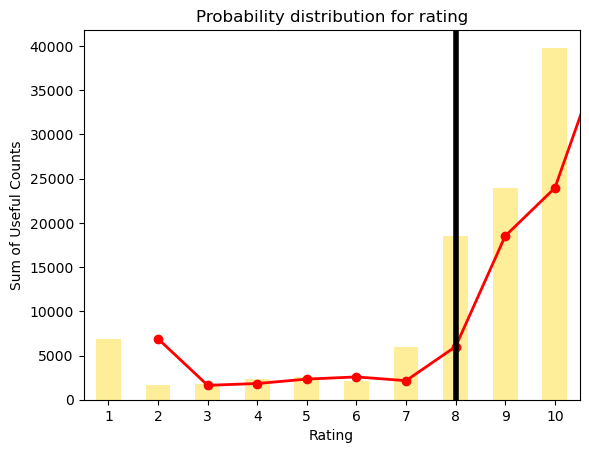

In [4]:
# Visualising the data for Average Rating

grouped_df.plot(kind='bar', x='rating', y='usefulCount', color = '#FFEE99')
grouped_df.plot(kind='line', x='rating', y='usefulCount', color='red', linewidth=2, marker='o')
plt.axvline(x=7, color='black', linestyle='-', linewidth=4)
plt.xlabel('Rating')
plt.ylabel('Sum of Useful Counts')
plt.title('Probability distribution for rating')
plt.show()

#### Web Crawling

In [5]:
# Install the web driver for web crawling
%pip install -q selenium webdriver-manager beautifulsoup4 lxml

Note: you may need to restart the kernel to use updated packages.


In [6]:
# Import module for scraping information from HTML
from bs4 import BeautifulSoup

# Import selenium modules
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager

def start_driver(headless=True):
    opts = Options()
    if headless: opts.add_argument("--headless=new")
    opts.add_argument("--window-size=1280,800")
    return webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=opts)

driver = start_driver(headless=False)

In [7]:
# Create a function to crawl data from web
def getData(url):
    driver.get(url)

    WebDriverWait(driver, 12).until(
        EC.presence_of_element_located((By.CSS_SELECTOR, "h1, .product-title, [class*='price']"))
    )

    # sold quantity
    soup = BeautifulSoup(driver.page_source, "lxml")
    page_text = soup.get_text(" ", strip=True)

    sold = None
    sold_div = soup.find('div', class_='salesNumber-container')
    if sold_div and sold_div.text.strip():
        sold = re.sub(r"[^\d]", "", sold_div.text)
    else:
        m = re.search(r"([0-9+,.]+)\s*Sold", page_text, re.I)
        if m: sold = re.sub(r"[^\d]", "", m.group(1))
    qsold.append(int(sold) if sold else None)

    # product name
    name_el = soup.select_one("h1") or soup.select_one("h1.last") or soup.select_one(".product-title")
    name = name_el.get_text(strip=True) if name_el else None
    if name:
        for m in re.findall(r"\[.*?]|\(.*?\)|&.*?;", name):
            name = name.replace(m, "")
        name = re.sub(r"\s{2,}", " ", name).strip()
    names.append(name)

    # selling price
    price = None
    disc = soup.find('span', class_='discount')
    if disc and disc.text.strip():
        price = re.sub(r"[^\d.]", "", disc.text)
    else:
        m = re.search(r"\$ ?([0-9,]+(?:\.[0-9]{2})?)", page_text)
        if m: price = m.group(1).replace(",", "")
    prices.append(float(price) if price else None)

    # customer rating
    rating = None
    rspan = soup.find('span', class_='averageRating')
    if rspan and rspan.text.strip():
        rtxt = re.sub(r"[^\d.]", "", rspan.text)
        rating = float(rtxt) if rtxt else None
    else:
        m = re.search(r"([0-9](?:\.[0-9])?)\s*/\s*5", page_text)  # e.g., "4.5 / 5"
        if m: rating = float(m.group(1))
    ratings.append(rating)

In [8]:
# Lists for saving data crawling from the web
names, prices, ratings, qsold = [], [], [], []
volumes     = [140, 35, 120, 100, 150, 80]
ingredients = [21, 6, 3, 4, 25, 18]

# URLs from HKTVmall
urls = [
    "https://www.hktvmall.com/hktv/en/main/Poonsme-medicine-and-beauty-%28Official%29/s/H6468002/Personal-Care-%26-Health/Personal-Care-%26-Health/Health/Bones-%26-Joints/Poons-Care-OSA40-Muscle-and-Joint-Gel-/p/H6468002_S_4897024477484",
    "https://www.hktvmall.com/hktv/en/main/Vita-Green/s/H0303001/Personal-Care-%26-Health/Personal-Care-%26-Health/Medicine/Pain-Patch-%26-Massage-Cream/VitaJoint-Muscle-Pain-Relief-Cream-35g-Expiry-Date-20251201/p/H0303001_S_VVJCR035PTHK01",
    "https://www.hktvmall.com/hktv/en/main/COME-ON-BABY-MART/s/H7353001/Personal-Care-%26-Health/Personal-Care-%26-Health/Medicine/Pain-Patch-%26-Massage-Cream/Counterpain-Taisho-Counterpain-cream-120g-8995201800684-Exp-Date-Oct-2026-Reg-NoHK65157/p/H7353001_S_PC-0374-1107",
    "https://www.hktvmall.com/hktv/en/main/Medimart/s/S1185001/Personal-Care-%26-Health/Personal-Care-%26-Health/Medicine/Pain-Patch-%26-Massage-Cream/Made-in-Korea-Pain-relief-gel-Natural-herbs/p/S1185001_S_FINM-00005",
    "https://www.hktvmall.com/hktv/en/main/Full-Health-Medical/s/S1068001/Personal-Care-%26-Health/Personal-Care-%26-Health/Medicine/Pain-Patch-%26-Massage-Cream/Muscles-Joints-Cryo-Pure-Spray-150ml-fast-relief-soothes-joint-tendon-ligament-muscle-pain/p/S1068001_S_Pure_musclespray",
    "https://www.hktvmall.com/hktv/en/main/Pharma-Cabinet/s/H6269001/Personal-Care-%26-Health/Personal-Care-%26-Health/Medicine/Pain-Patch-%26-Massage-Cream/PUTTINGERWarm-Therapy-Gel-7232EXPIRY-20280630/p/H6269001_S_HM-ES_15P15",
]

# Web crawl
for u in urls:
    try:
        getData(u)
    except Exception as e:
        print("Failed:", u, e)
        names.append(None); prices.append(None); ratings.append(None); qsold.append(None)

In [9]:
# Dataframe to display data collected from crawling

df1 = pd.DataFrame({'Drug': names, 'Price': prices, 'Volume': volumes, 'Rating': ratings, 'M. Ingred.': ingredients})
df1.head()

,Drug,Price,Volume,Rating,M. Ingred.
0,Poon's - Poon's Care OSA-40 Muscle and Joint Gel,238.0,140,4.6,21
1,VITA GREEN - VitaJoint™ Muscle Pain Relief Cre...,159.0,35,3.0,6
2,Counterpain - Counterpain Taisho Counterpain c...,63.8,120,4.4,3
3,Spocool - Made in Korea - Pain relief gel - Na...,144.4,100,4.2,4
4,Puressentiel - Muscles & Joints Cryo Pure Spra...,249.0,150,5.0,25


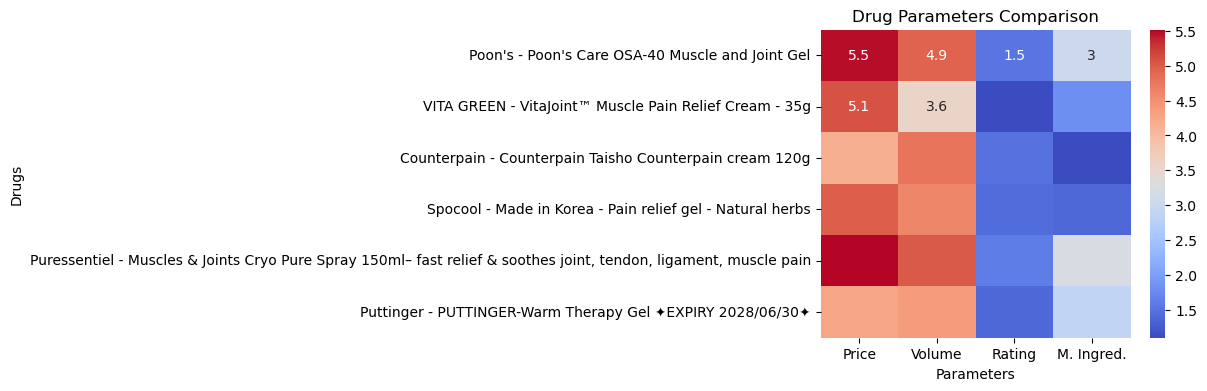

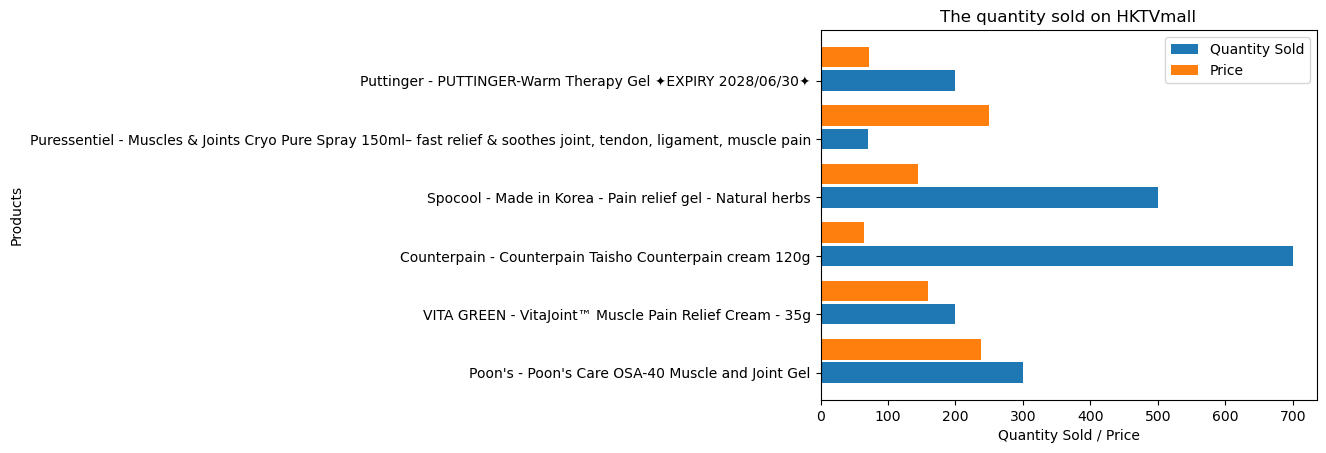

In [10]:
# Heatmap
df1.set_index('Drug', inplace=True)
plt.figure(figsize=(5, 4))
sns.heatmap(np.log(df1), cmap='coolwarm', annot=True, cbar=True)
plt.title('Drug Parameters Comparison')
plt.xlabel('Parameters')
plt.ylabel('Drugs')
plt.show()

# Horizontal bar chart
xposition = np.arange(len(names))
plt.barh(xposition-0.2, qsold, height = 0.35, label = 'Quantity Sold')
plt.barh(xposition+0.2, prices, height = 0.35, label = 'Price')
plt.yticks(xposition-0.2, names)
plt.ylabel('Products')
plt.xlabel('Quantity Sold / Price')
plt.title('The quantity sold on HKTVmall')
plt.legend()
plt.show()

#### Impact of Price on Satisfaction and Effectiveness

##### Data filtering:

In [11]:
wanted_categories = ['pain', 'gout']
filtered_df = df2[df2['Condition'].isin(wanted_categories)]

new_df = filtered_df[['Drug', 'EaseOfUse', 'Effective', 'Price', 'Reviews', 'Satisfaction']]

stat_price = new_df['Price'].describe()
stat_reviews = new_df['Reviews'].describe()
new_df = new_df[new_df['Price'] <= 500]
new_df = new_df[new_df['Reviews'] <= 600]

##### Visualising data:

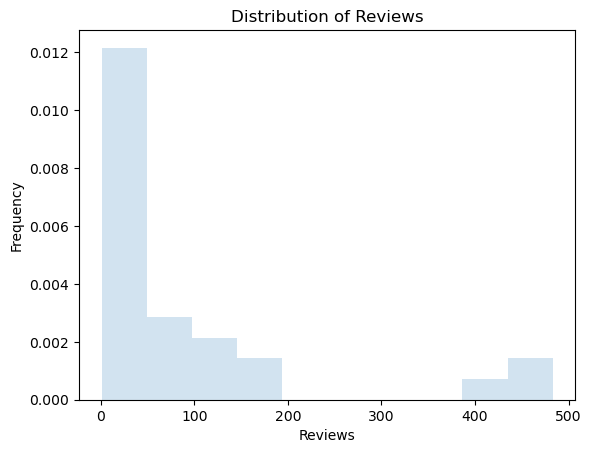

In [12]:
# Histogram for Reviews

plt.hist(new_df['Reviews'], bins=10, density=True, alpha=0.2)
plt.xlabel('Reviews')
plt.ylabel('Frequency')
plt.title('Distribution of Reviews')
plt.show()

# Fit a normal distribution curve to the data
mu, sigma = new_df['Reviews'].mean(), new_df['Reviews'].std()
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
pdf = stats.norm.pdf(x, mu, sigma)

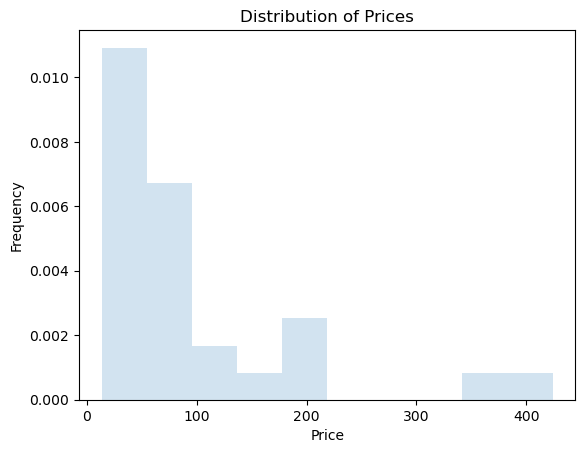

In [13]:
# Histogram for Prices

plt.hist(new_df['Price'], bins=10, density=True, alpha=0.2)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Prices')
plt.show()

# Fit a normal distribution curve to the data
mu, sigma = new_df['Price'].mean(), new_df['Price'].std()
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
pdf = stats.norm.pdf(x, mu, sigma)

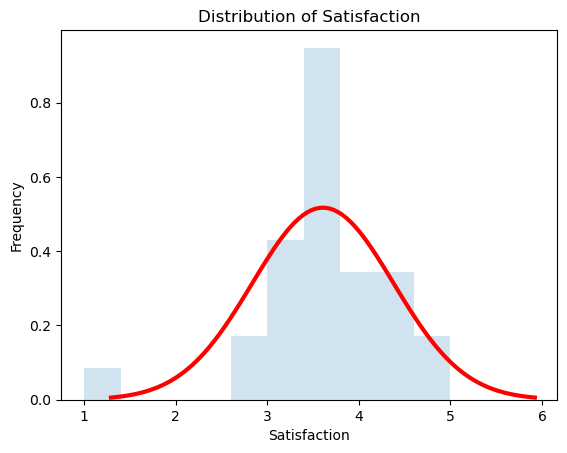

In [14]:
# Histogram for Satisfaction Levels

plt.hist(new_df['Satisfaction'], bins=10, density=True, alpha=0.2)
plt.xlabel('Satisfaction')
plt.ylabel('Frequency')
plt.title('Distribution of Satisfaction')

# Fit a normal distribution curve to the data
mu, sigma = new_df['Satisfaction'].mean(), new_df['Satisfaction'].std()
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
pdf = stats.norm.pdf(x, mu, sigma)
plt.plot(x, pdf, 'r-', linewidth=3)

#### Correlation between Price, Effectiveness, and Customer Satisfaction

##### Filtering data:

In [ ]:
filtered_df = df2[df2['Condition'].str.contains('pain' or 'joint' or'muscle', case = False, na = False)]
new_df = filtered_df[['Price','Effective','Satisfaction']]
new_df = new_df[new_df['Price'] <= 25]

##### Visualising data:

In [15]:
# Correlation analysis between price, effectiveness and satisfaction

correlation1 = new_df['Price'].corr(new_df['Effective'])
print(f"Correlation between price and effectiveness is {correlation1}")
correlation2 = new_df['Price'].corr(new_df['Satisfaction'])
print(f"Correlation between price and satisfaction is {correlation2}")
correlation3 = new_df['Satisfaction'].corr(new_df['Effective'])
print(f"Correlation between satisfaction and effectiveness is {correlation3} \n")

# Tabulate the results
data = {'Variable 1': ['Price','Price','Satisfaction'],
        'Variable 2': ['Effectiveness', 'Satisfaction', 'Effectiveness'],
        'Correlation': [correlation1, correlation2, correlation3]}
cf = pd.DataFrame(data)
table = tabulate(cf, headers='keys', tablefmt='fancy_grid', stralign = 'center')
print(table)

Coorelation between price and effectiveness is -0.3971024888843745
Coorelation between price and satisfaction is -0.3603214221146191
Coorelation between satisfactio and effectiveness is 0.45603211377809927 

╒════╤══════════════╤═══════════════╤═══════════════╕
│    │  Variable 1  │  Variable 2   │   Correlation │
╞════╪══════════════╪═══════════════╪═══════════════╡
│  0 │    Price     │ Effectiveness │     -0.397102 │
├────┼──────────────┼───────────────┼───────────────┤
│  1 │    Price     │ Satisfaction  │     -0.360321 │
├────┼──────────────┼───────────────┼───────────────┤
│  2 │ Satisfaction │ Effectiveness │      0.456032 │
╘════╧══════════════╧═══════════════╧═══════════════╛


#### Impact of Gender on Customer Satisfaction

##### Filtering data:

In [ ]:
filtered_df = df3[df3['Condition'].str.contains('joint|muscle', case=False, na=False)]
pain_df = filtered_df.dropna(subset=['Sex'])

gender_counts = pain_df.groupby('Sex').size()

male_consumers = gender_counts['Male']
female_consumers = gender_counts['Female']
total_consumers = male_consumers + female_consumers

proportion_male = male_consumers / total_consumers
proportion_female = female_consumers / total_consumers
proportions = [proportion_male, proportion_female]
labels = ["male", "female"]

##### Visualing data:

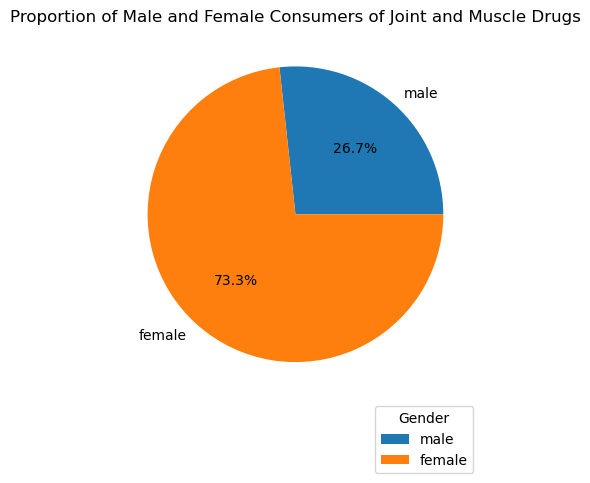

In [16]:
# Pie chart of genders

plt.pie(proportions, labels=labels, autopct='%1.1f%%')
plt.legend(title='Gender', bbox_to_anchor=(1,0), loc='upper right')
plt.title('Proportion of Male and Female Consumers of Joint and Muscle Drugs')
plt.show()

In [ ]:
# Only consider pain for joint and muscle conditions
def pain_conditions(df2):
    filtered_df = df2[df2['Condition'].str.contains('joint|muscle', case=False)]
    return filtered_df

# Drop null values in sex and satisfaction
def drop_null_values(df2):
    cleaned_df = df2.dropna(subset=['Sex', 'Satisfaction'])
    return cleaned_df

# Only consider pain drug with satisfaction values for both male and female
def pain_drugs(df2):
    grouped_df = df2.groupby('Drug')
    pain_drugs = []
    for name, group in grouped_df:
        if set(group['Sex']) == {'Male', 'Female'} and len(group) > 1:
            pain_drugs.append(name)
    filtered_df = df2[df2['Drug'].isin(pain_drugs)]
    return filtered_df

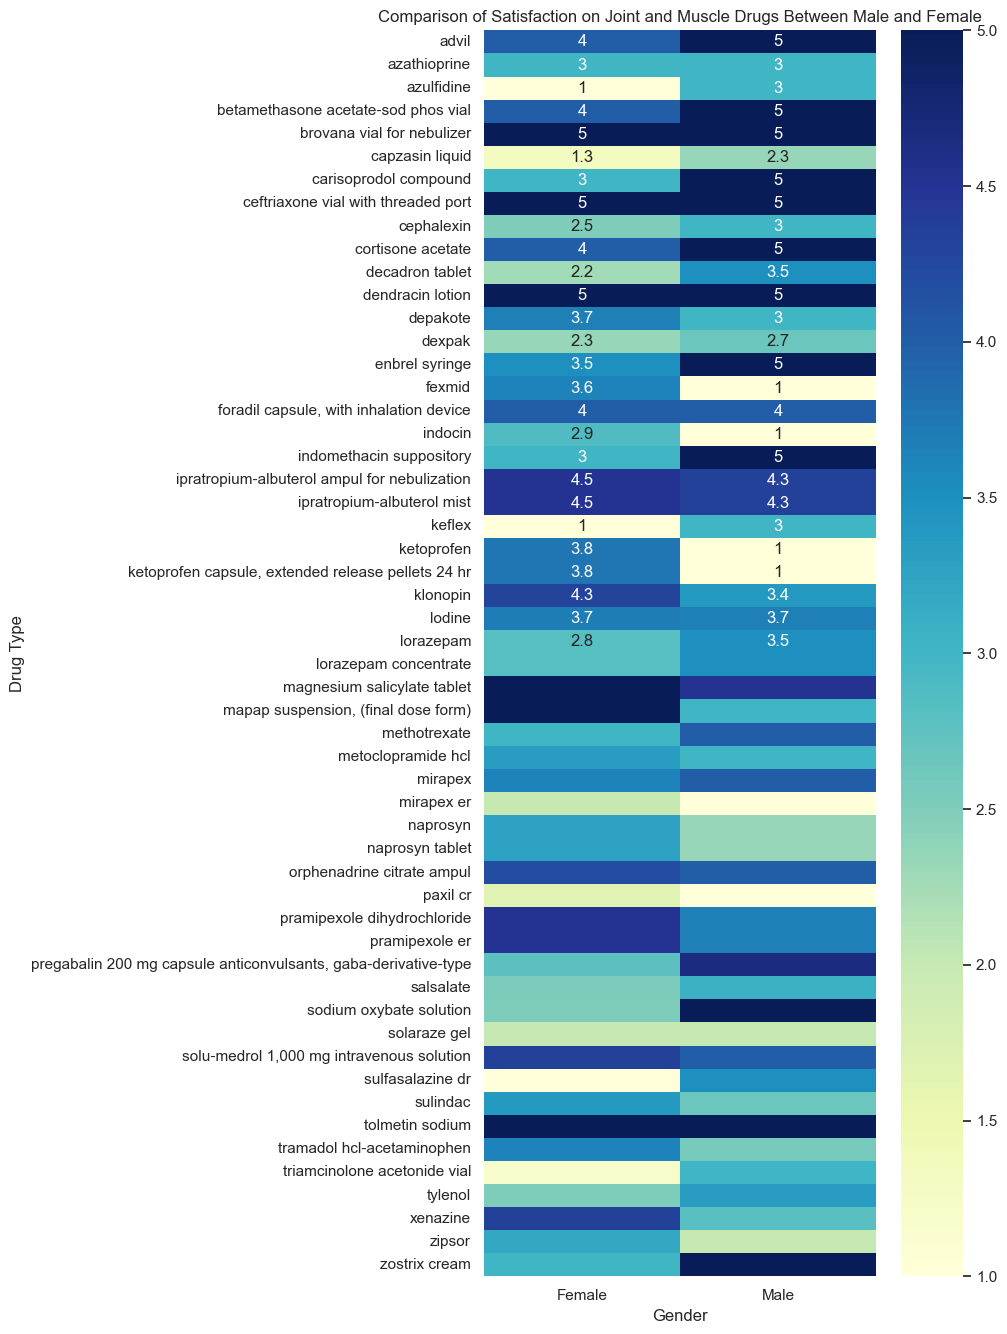

In [17]:
# Plot the heat map to show the distribution of customer ratings by gender

def create_heatmap(df2):
    pivot_df = df2.pivot_table(index='Drug', columns='Sex', values='Satisfaction')
    font_size = 10
    figure_height = len(pivot_df) * (font_size / 40)
    sns.set(font_scale=font_size / 10)
    plt.figure(figsize=(10, figure_height))
    
    sns.heatmap(pivot_df, annot=True, cmap='YlGnBu')
    plt.title('Comparison of Satisfaction on Joint and Muscle Drugs Between Male and Female')
    plt.xlabel('Gender')
    plt.ylabel('Drug Type')
    plt.tight_layout()
    plt.show()

df2 = pd.read_csv('webmd.csv')
df2 = pain_conditions(df2)
df2 = drop_null_values(df2)
df2 = pain_drugs(df2)
create_heatmap(df2)

#### Impact of Ingredient List on Sales Performance

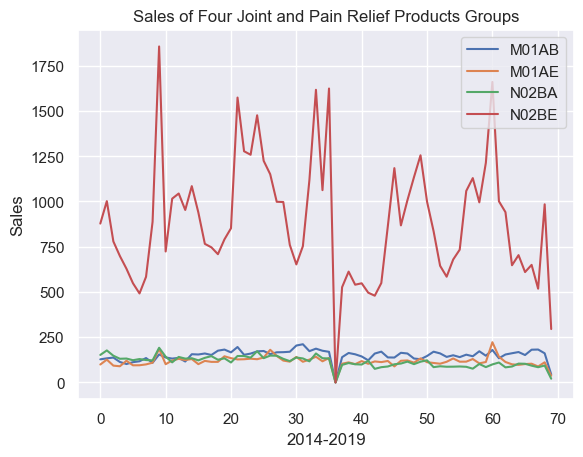

In [18]:
# Line graph for sales records

plt.plot(sales['M01AB']); plt.plot(sales['M01AE'])
plt.plot(sales['N02BA']); plt.plot(sales['N02BE'])
plt.xlabel('2014-2019')
plt.ylabel('Sales')
plt.title('Sales of Four Joint and Pain Relief Products Groups')
plt.legend(["M01AB", "M01AE","N02BA","N02BE"])
plt.show()

#### Monte Carlo Simulation

*Perform a Monte Carlo on Success, Effectiveness, Ease of Use, and Price per quantity ratio threshold levels to determine factors that can be sufficient to call a product successful. The successful threshold was determined based on a review of the literature.*

##### First Simulation:

Mean success rate: 0.731893
95% confidence interval: [0.64 0.81]
The estimated success rate is 73.18611987381703%


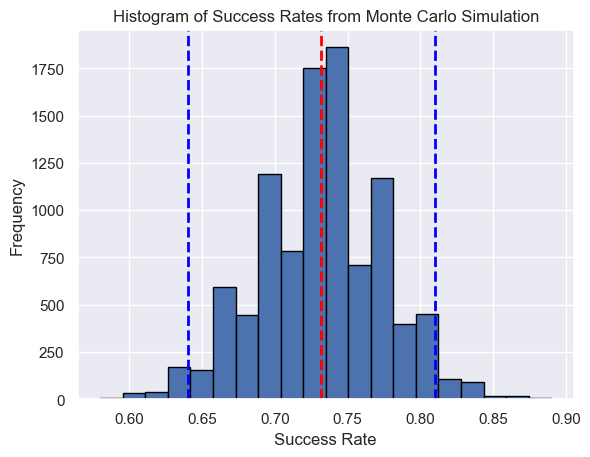

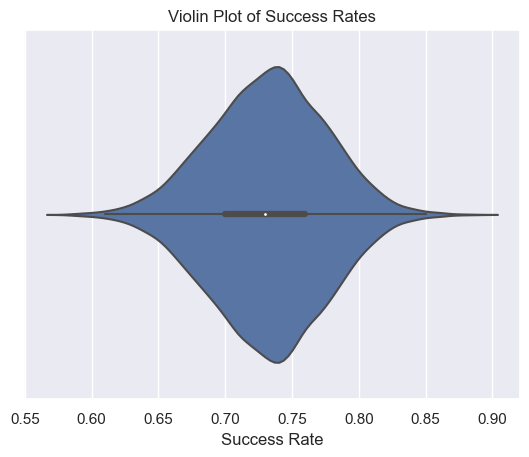

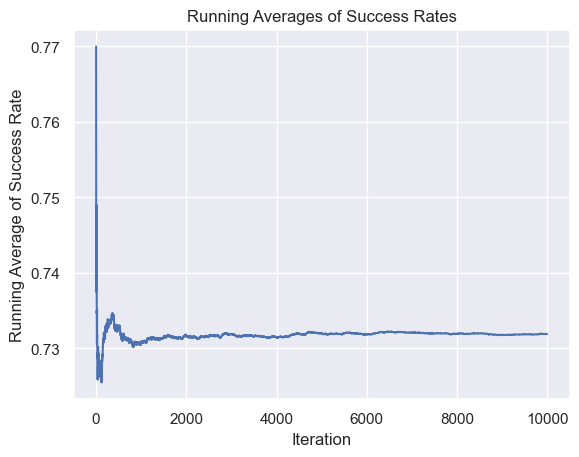

In [19]:
def drug_csv():

    df = pd.read_csv('Drug.csv')
    
    # Define the thresholds for success
    effectiveness_threshold = 3.55
    ease_of_use_threshold = 3.95
    satisfaction_threshold = 3.22

    # Define a function to simulate a scenario
    def simulate_scenario(row):
        effectiveness = row['Effective']
        ease_of_use = row['EaseOfUse']
        satisfaction = row['Satisfaction']
        # Define a probabilistic model based on the parameters
        if effectiveness > effectiveness_threshold or ease_of_use > ease_of_use_threshold or satisfaction > satisfaction_threshold:
            success = 1
        else:
            success = 0
        return success

    # Apply the Monte Carlo simulation to each row of the DataFrame
    df['SimulationResult'] = df.apply(simulate_scenario, axis=1)

    n_iterations = 10000
    n_samples = 100

    results = []
    for _ in range(n_iterations):
        sample = df.sample(n_samples)
        success_rate = sample['SimulationResult'].mean()
        results.append(success_rate)

    # Mean success rate and confidence interval calculation of iterations
    mean_success_rate = np.mean(results)
    confidence_interval = np.percentile(results, [2.5, 97.5])

    print('Mean success rate:', mean_success_rate)
    print('95% confidence interval:', confidence_interval)

    # Calculate the success rate
    success_rate = df['SimulationResult'].mean()
    print(f'The estimated success rate is {success_rate * 100}%')

    # Histogram of results
    plt.hist(results, bins=20, edgecolor='black')
    plt.axvline(mean_success_rate, color='red', linestyle='dashed', linewidth=2)
    plt.axvline(confidence_interval[0], color='blue', linestyle='dashed', linewidth=2)
    plt.axvline(confidence_interval[1], color='blue', linestyle='dashed', linewidth=2)
    plt.title('Histogram of Success Rates from Monte Carlo Simulation')
    plt.xlabel('Success Rate')
    plt.ylabel('Frequency')
    plt.show()

    # Violin Plot of the results
    sns.violinplot(x=results)
    plt.xlabel('Success Rate')
    plt.title('Violin Plot of Success Rates')
    plt.show()

    # Line Plot of Running Averages
    cumulative_averages = np.cumsum(results) / (np.arange(len(results)) + 1)
    plt.plot(cumulative_averages)
    plt.xlabel('Iteration')
    plt.ylabel('Running Average of Success Rate')
    plt.title('Running Averages of Success Rates')
    plt.show()

drug_csv()

##### Second Simulation:

Mean success rate: 0.81328
95% confidence interval: [0.36 1.  ]


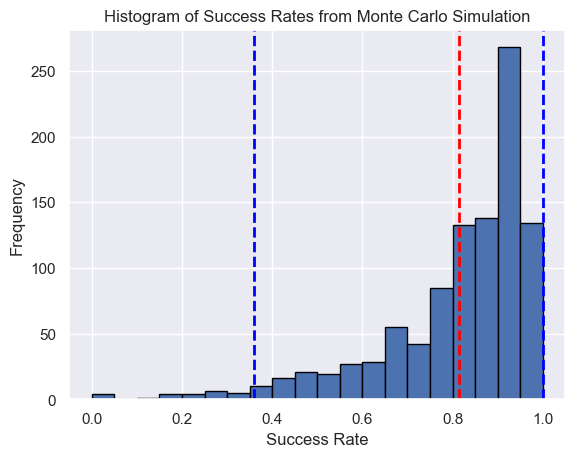

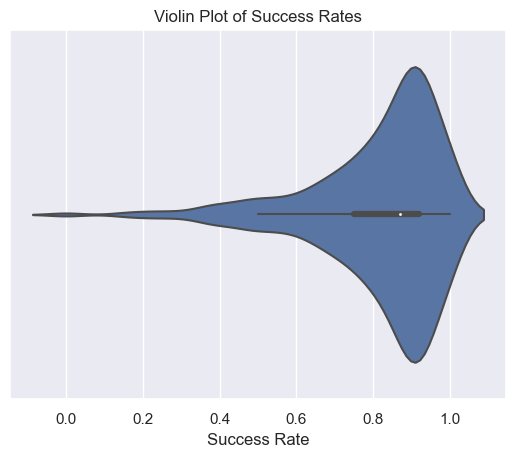

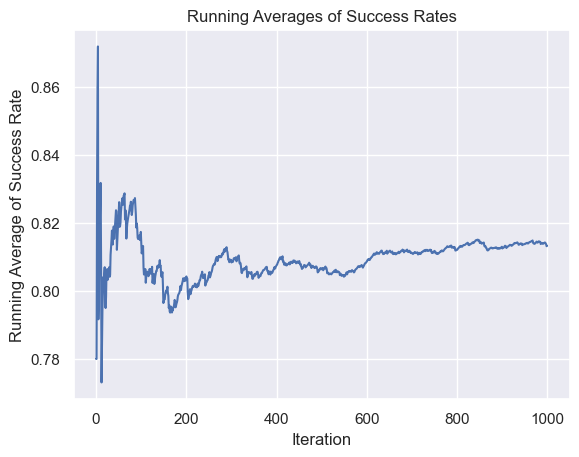

In [20]:
def drug_csv():

    df = pd.read_csv('Drug.csv')
    
    n_iterations = 1000
    n_samples = 100

    results = []
    thresholds = []

    for _ in range(n_iterations):

        # Define the thresholds for success
        effectiveness_threshold = abs(np.random.normal(loc=3.55, scale=1.23))
        ease_of_use_threshold = abs(np.random.normal(loc=3.95, scale=1.08))
        satisfaction_threshold = abs(np.random.normal(loc=3.22, scale=1.52))

        thresholds.append((effectiveness_threshold, ease_of_use_threshold, satisfaction_threshold))

        # Define a function to simulate a scenario
        def simulate_scenario(row):
            effectiveness = row['Effective']
            ease_of_use = row['EaseOfUse']
            satisfaction = row['Satisfaction']
            
            # Define a probabilistic model based on the parameters
            if effectiveness > effectiveness_threshold or ease_of_use > ease_of_use_threshold or satisfaction > satisfaction_threshold:
                success = 1
            else:
                success = 0
            return success

        # Apply the Monte Carlo simulation to each row of the DataFrame
        df['SimulationResult'] = df.apply(simulate_scenario, axis=1)

        sample = df.sample(n_samples)
        success_rate = sample['SimulationResult'].mean()
        results.append(success_rate)

    # Mean success rate and confidence interval calculation of iterations
    mean_success_rate = np.mean(results)
    confidence_interval = np.percentile(results, [2.5, 97.5])
    print('Mean success rate:', mean_success_rate)
    print('95% confidence interval:', confidence_interval)

    # Plot histogram of results
    plt.hist(results, bins=20, edgecolor='black')
    plt.axvline(mean_success_rate, color='red', linestyle='dashed', linewidth=2)
    plt.axvline(confidence_interval[0], color='blue', linestyle='dashed', linewidth=2)
    plt.axvline(confidence_interval[1], color='blue', linestyle='dashed', linewidth=2)
    plt.title('Histogram of Success Rates from Monte Carlo Simulation')
    plt.xlabel('Success Rate')
    plt.ylabel('Frequency')
    plt.show()

    # Violin Plot of the results
    sns.violinplot(x=results)
    plt.xlabel('Success Rate')
    plt.title('Violin Plot of Success Rates')
    plt.show()

    # Line Plot of Running Averages
    cumulative_averages = np.cumsum(results) / (np.arange(len(results)) + 1)
    plt.plot(cumulative_averages)
    plt.xlabel('Iteration')
    plt.ylabel('Running Average of Success Rate')
    plt.title('Running Averages of Success Rates')
    plt.show()

drug_csv()